# ScopeSim Sources

## ScopeSim `Source` and `SourceField` Overview

### What is a `Source`?

`Source` is the top-level target container passed into `OpticalTrain.observe()`.
It combines:

- **Spatial information**: where light is on sky (`source.fields`)
- **Spectral information**: what spectrum each component has (`source.spectra`)
- **Metadata**: extra context (`source.meta`)

A single `Source` can hold multiple components (e.g., stars + diffuse background + cube).

---

### What is a `SourceField`?

`Source.fields` is a list that stores `SourceField` objects representing one spatial/spectral component.

Available field types (subclasses of `SourceField`):

1. **`TableSourceField`**
   - Stores an `astropy.table.Table` with point-source rows.
   - Typical columns: `x`, `y`, `ref`, `weight`.
   - `ref` maps each row to an entry in `source.spectra`.

2. **`ImageSourceField`**
   - Stores a 2D `fits.ImageHDU` (surface-brightness map).
   - Uses WCS in header for sky-to-pixel mapping.
   - Usually linked to one spectrum via header metadata (e.g., `SPEC_REF`).

3. **`CubeSourceField`**
   - Stores a 3D cube (`fits.ImageHDU`) with spatial + wavelength axes.
   - Contains its own spectral axis (not just one average spectrum).

---

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.table import Table, vstack
from astropy.io import fits

import scopesim_templates as sim_tp
from scopesim.source.source import Source
from scopesim.source.source_fields import TableSourceField, ImageSourceField, CubeSourceField
import scopesim.source.source_templates  as source_templates
import scopesim.source.source_utils as source_utils

def plot_source(source):
    wave = np.linspace(0.3, 2.5, 1001) * u.um
    num_fields = len(source.fields)
    fig, axs = plt.subplots(figsize=(6,2*num_fields), nrows=num_fields, ncols=2, width_ratios=[1,2], constrained_layout=True)
    if num_fields == 1:
        axs = np.array([axs])
    for i, field in enumerate(source.fields):
        ax1, ax2 = axs[i]
        ax1.imshow(field.data, origin='lower', cmap='viridis')
        ax2.plot(wave, field.spectrum(wave))
        ax1.set_title('Spatial Profile')
        ax1.set_xlabel('X (arcsec)')
        ax1.set_ylabel('Y (arcsec)')
        ax2.set_title('Spectrum')
        ax2.set_xlabel('Wavelength (um)')
        ax2.set_ylabel(r'Flux (ph s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)')

/Users/yashvi/Desktop/ZShooter/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## How to create `Source` objects

### A) From a point-source table + spectra

In [2]:
tbl = Table(
    data=[[0.0, 1.2], [0.0, -0.5], [0, 0], [1.0, 0.7]],
    names=["x", "y", "ref", "weight"],
)
tbl["x"].unit = u.arcsec
tbl["y"].unit = u.arcsec

ps = Source(table=tbl, spectra=[source_templates.vega_spectrum(10)])
ps.fields

[TableSourceField(field=<Table length=2>
    x       y     ref   weight
  arcsec  arcsec              
 float64 float64 int64 float64
 ------- ------- ----- -------
     0.0     0.0     0     1.0
     1.2    -0.5     0     0.7, spectra={0: <synphot.spectrum.SourceSpectrum object at 0x11205ee10>})]

### B) From an image HDU + spectrum


[ImageSourceField(field=<astropy.io.fits.hdu.image.ImageHDU object at 0x1139d55b0>, wcs=WCS Keywords

Number of WCS axes: 2
CTYPE : '' ''
CUNIT : 'deg' 'deg'
CRVAL : 0.0 0.0
CRPIX : 0.0 0.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : 0.000277777777777777 0.000277777777777777
NAXIS : 64  64, spectra={0: <synphot.spectrum.SourceSpectrum object at 0x10de474a0>})]


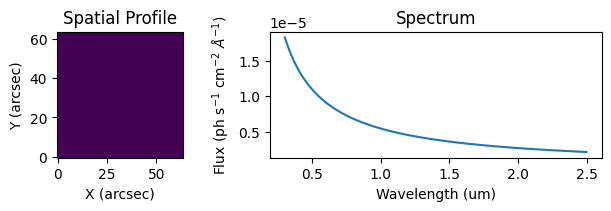

In [3]:
img = np.ones((64, 64), dtype=float)
hdr = fits.Header(cards={'CUNIT1':'arcsec', 'CUNIT2':'arcsec', 'CDELT1':1, 'CDELT2':1}) # need to include this minimal header
hdu = fits.ImageHDU(data=img, header=hdr)

im = Source(image_hdu=hdu, spectra=[source_templates.ab_spectrum(mag=20)]) # ab_spectrum creates a spectrum with constant flux in magnitude space of given mag (which does not mean constant in erg/s/cm2/Angstrom)
print(im.fields)
plot_source(im)


NOTE: Can also use `src.source_templates.uniform_source()` to create the above source in one step as shown below. The default spatial sampling is 1 arcsec/pixel.

[ImageSourceField(field=<astropy.io.fits.hdu.image.ImageHDU object at 0x113cbc830>, wcs=WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 0.0 0.0
CRPIX : 32.5 32.5
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -0.00027777777777778 0.00027777777777778
NAXIS : 64  64, spectra={0: <synphot.spectrum.SourceSpectrum object at 0x113acede0>})]


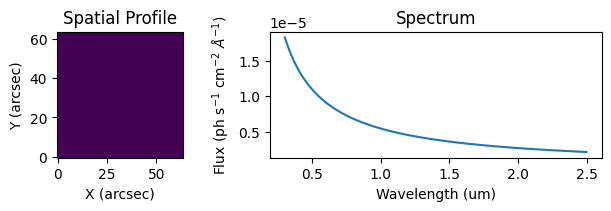

In [4]:
im2 = source_templates.uniform_source(source_templates.ab_spectrum(mag=20), extent=64)
print(im2.fields)
plot_source(im2)

To create a uniform source in PHOTLAM units (photons/s/cm^2/Angstrom), use `ConstFlux1D` with the appropriate amplitude (e.g., 0.001 for 1 photon/s/cm^2/Angstrom):

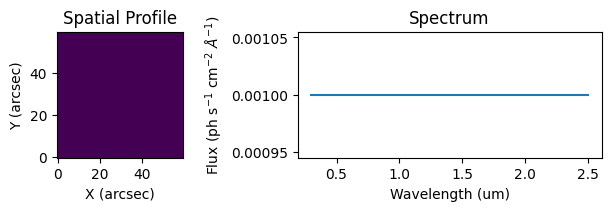

In [5]:
sp = source_templates.ConstFlux1D(amplitude=0.001) # synphot model, default unit is photon/s/cm^2/Angstrom
waves = np.geomspace(100, 300000, 50000)
lookup = sp(waves)
im3 = source_templates.uniform_source(
                                    source_templates.SourceSpectrum(source_templates.Empirical1D, points=waves, lookup_table=lookup),  # synphot spectrum
                                    extent=60)
plot_source(im3)

### C) From helper templates (quick start) available in `scopesim_templates` package

<Axes: xlabel='x [arcsec]', ylabel='y [arcsec]'>

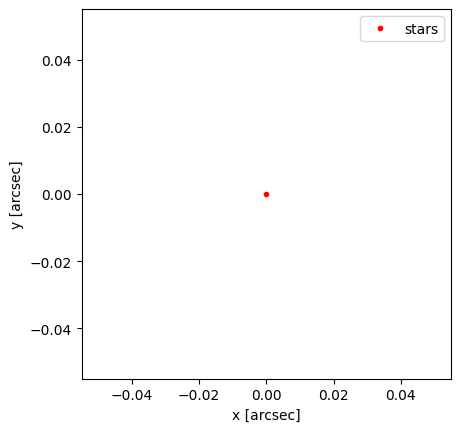

In [6]:
# star
star = sim_tp.star(filter_name='V', amplitude=10*u.ABmag) # spectra taken from 'spextra' package
star.plot()

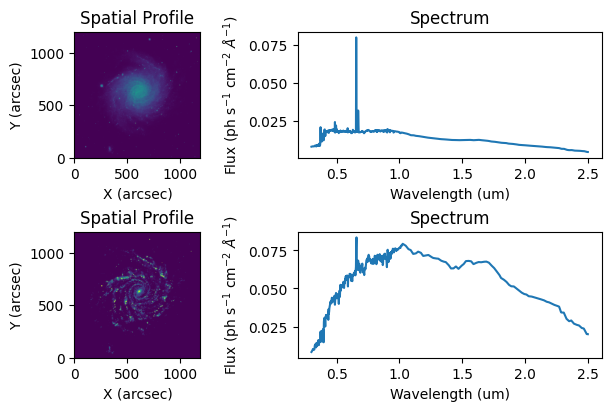

In [7]:
# Galaxy
gal = sim_tp.extragalactic.galaxies.spiral_two_component(extent=200*u.arcsec, fluxes=(15, 15)*u.mag)  # loaded from saved fits template of NGC1232L
gal.shift(dy=-30*0.004)
plot_source(gal)

Other available galaxy models include `galaxy`, `galaxy3d`, and `elliptical`. See `scopesim_templates.extragalactic.galaxies` for details.

## Useful sources

### A uniform source to simulate dome flats

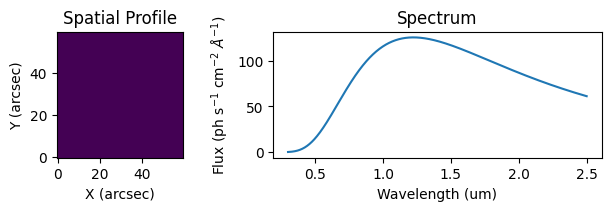

In [8]:
# Let's say we want a high-power halogen bulb emitting a 3000 K blackbody spectrum, uniformly illuminating a 1 arcmin x 1 arcmin area on the sky. We can create this source as follows:
domeflat = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=4*u.ABmag, filter_curve='V', extend=60)
plot_source(domeflat)

### Arc lamps for wavelength calibration

In [9]:
# load line list
uvb = Table.read('line_lists/ThAr_XSHOOTER_UVB_lines.dat', delimiter='|', format='ascii', header_start=0)
neir = Table.read('line_lists/Ne_IR_MOSFIRE_lines.dat', delimiter='|', format='ascii', header_start=0)
arir = Table.read('line_lists/Ar_IR_MOSFIRE_lines.dat', delimiter='|', format='ascii', header_start=0)
lines = vstack([uvb, neir, arir])
lines

col0,wave,ion,NIST,Instr,amplitude,Source,_1
int64,float64,str4,int64,int64,float64,str20,int64
--,3094.261313368305,ThAr,1,32,218.70677052723238,wavemodel.py,--
--,3140.0171522371547,ThAr,1,32,148.12281124090538,wavemodel.py,--
--,3170.5540268969266,ThAr,1,32,158.8138285062605,wavemodel.py,--
--,3181.1243070684113,ThAr,1,32,227.88057703827917,wavemodel.py,--
--,3189.181869102448,ThAr,1,32,222.56046465150408,wavemodel.py,--
--,3233.222527087156,ThAr,1,32,199.46752294459446,wavemodel.py,--
--,3239.0583334075486,ThAr,1,32,145.47867955933862,wavemodel.py,--
--,3244.661251438086,ThAr,1,32,208.4018341765855,wavemodel.py,--
--,3245.1958097699485,ThAr,1,32,253.38302082586046,wavemodel.py,--


In [10]:
R = 60000 # desired spectral resolution

centers = np.array(lines['wave']).astype(float)  # in Angstrom
fwhms = 2.6*(centers/R) # nyquist sampled
stddevs = fwhms / (2*np.sqrt(2*np.log(2)))
amps = np.array(lines['amplitude']).astype(float)

waves = np.arange(3000, 25000, 0.5/R)
# Fast sparse Gaussian accumulation — only touches pixels within ±10σ per line
sp = np.zeros(len(waves))
dw = 0.5/R

for cen, std, amp in zip(centers, stddevs, amps):
    hw = int(np.ceil(10 * std / dw))          # half-window in pixels
    idx = int(round((cen - waves[0]) / dw))  # center pixel
    lo = max(0, idx - hw)
    hi = min(len(waves), idx + hw + 1)
    w_local = waves[lo:hi]
    sp[lo:hi] += amp * np.exp(-(w_local - cen)**2 / (2 * std**2))

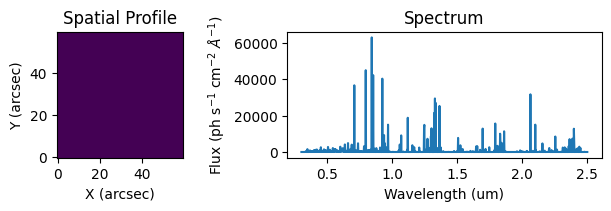

In [11]:
lamp1 = source_templates.uniform_source(
                                    source_templates.SourceSpectrum(source_templates.Empirical1D, points=waves, lookup_table=sp),  # synphot spectrum
                                    extent=60)
plot_source(lamp1)

**NOTE** Plotting results for higher values of R takes forever because the array size gets pretty large

### Extragalactic transient: Supernova

Template spectra can be pulled from A-star Vienna's spextra package library:
https://scopesim.univie.ac.at/spextra/database/libraries/
``` python
from spextra import Spextrum
sed = Spextrum('brown/NGC3870')
```

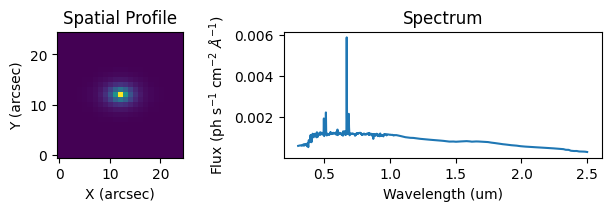

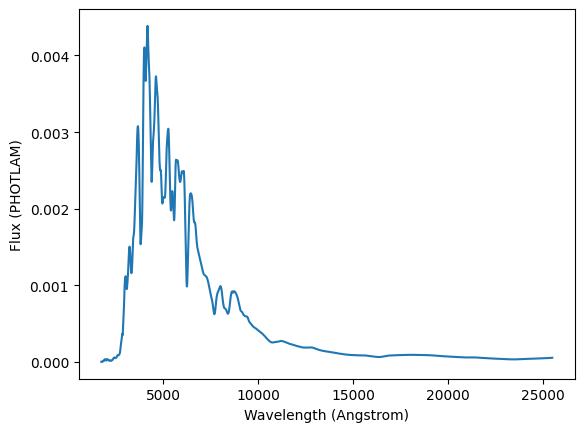

In [23]:
# base galaxy
gal = sim_tp.galaxy(sed='brown/NGC3870', z=0.02, amplitude=15, filter_curve='g', pixel_scale=1, r_eff=2.5, n=1., ellip=0.3, theta=0, extend=5)
plot_source(gal)

# download spectrum from spextra library
from spextra import Spextrum
sed = Spextrum('sne/sn1a').redshift(0.02) # redshift it to match the host galaxy
spec = sed.scale_to_magnitude(14*u.ABmag, 'g')
spec.plot()
# add sn to gal at 5",5" offset from center
gal.append(Source(spectra=spec, x=[5.0], y=[5.0], ref=[0.], weight=[1.0]))

astar.scopesim.optics.image_plane - No BUNIT found in added HDU.
py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/ScopeSim/scopesim/source/source.py:501: DeprecationWarning: Adding a table directly to the ImagePlane is deprecated since v0.10.0. Passing a table to ImagePlane.add() will raise an error from version 0.12 onwards. Use FOV to add tables and image HDUs together before.
  im_plane.add(hdu_or_table, sub_pixel=sub_pixel,



(<Figure size 640x480 with 2 Axes>, <Axes: >)

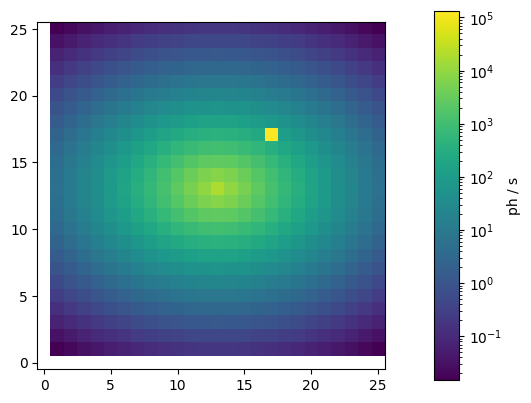

In [22]:
im = gal.image(wave_min=0.3, wave_max=2.5, pixel_scale=1*u.arcsec)
im.plot()